In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities
import python.solvers as solvers

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(solvers);

---


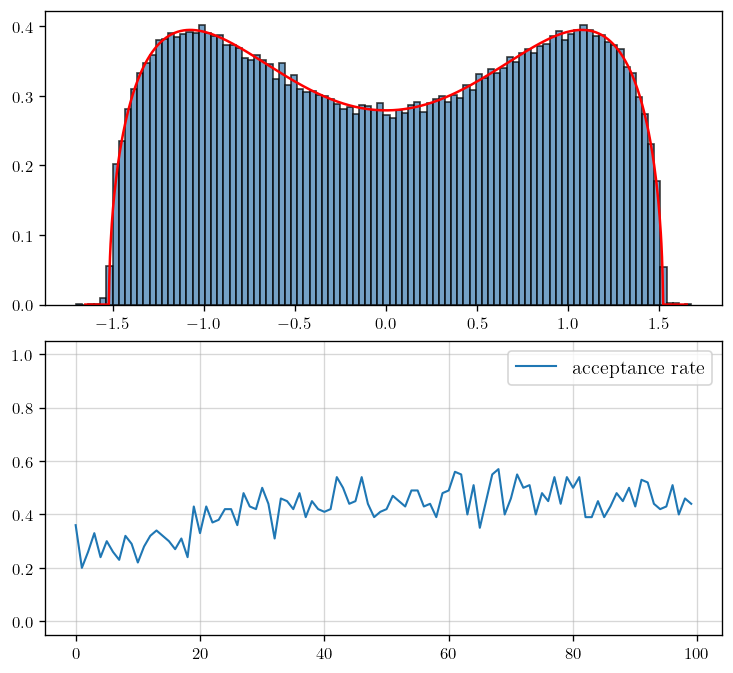

In [8]:
N = 70; beta = 2.0; T = 10.0; M = 100; 
potential_name = "quartic"; num_bins = 100;     
metropolise = True
dt = 0.1

total_steps = int(T/dt); init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

pipe = simulate.get_pipeline("imla", dt = dt, noise_scale = noise_scale, potential_type = potential_name, beta = beta, metropolise = metropolise)
traj = simulate.simulate_dbm(init, total_steps, pipe)

burn_in = int(3.0/dt) # at T = 3.0, for longer simulations change.
particles, accepts = simulate.metropolis_experiment(traj, total_steps, burn_in = burn_in, interval = 5)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, axes = plt.subplots(2, 1, figsize = (6, 5.5))
ax, ax2 = axes 

ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
ax.grid(False)

x_range = list(range(len(accepts)))
ax2.plot(x_range, accepts, label = "acceptance rate")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc = "upper right", fontsize = 12)

plt.show()

---

Similar experiment to as done for the HMC (Robbins-Munro type).
- For each $N$ adapatively tune $dt$ so that a target acceptance rate is hit (e.g. 50%).
    - Run MAIMLA until $T = 10.0$ for different dts. Look at acceptance rate for $T > 5$ (it is probably fine to take it smaller). Take avg. acceptance rate for this post burn in. 
    - Adjust dt accordingly.
    - Maximum iterations $10^5$ for now, try $N$ in even logspace between $0$ and $300$?

In [17]:
importlib.reload(simulate);

N_range = np.logspace(np.log10(50), np.log10(500), 5, dtype = int)
num_steps = 100; M = 100; # NOTE do much longer (e.g. 10**4) later.
beta = 2.0; pot_int = 2 # Quartic.

target = 0.5
imla_target_results = {}

print(N_range)

for N in N_range:
    init = random_matrix.init_gue_eigenvalues(M, N)
    dt_history = []; accept_history = [];
    
    traj = simulate.imla_target_dt(init, num_steps, pot_int, beta, dt_init = 1/(N**1/2), target = target)
    for step_idx, dt, accept_rate in traj:
        dt_history.append(dt)
        accept_history.append(accept_rate)
        
        """
        if step_idx % 30 == 0:
            print(f"(N = {N}) Step {step_idx}: dt = {dt:.6f}, Acceptance = {accept_rate*100:.1f}%")
        """

    print(f"N = {N} -- final tuned dt {dt_history[-1]:.6f}, final accept {accept_history[-1]:.6f}")

    imla_target_results[(N)] = {"dt_history": dt_history, "accept_history": accept_history, 
                                "final_dt": dt_history[-1], "final_accept": accept_history[-1]}

[ 49  88 158 281 499]
N = 49 -- final tuned dt 0.049195, final accept 0.700000
N = 88 -- final tuned dt 0.024325, final accept 0.620000
N = 158 -- final tuned dt 0.011930, final accept 0.500000
N = 281 -- final tuned dt 0.005974, final accept 0.380000
N = 499 -- final tuned dt 0.003020, final accept 0.230000


In [18]:
final_dts = [imla_target_results[(N)]["final_dt"] for N in N_range]
fig, ax = plt.subplots()

ax.loglog(N_range, final_dts, marker = 'o', markersize = 3)
np.polyfit(np.log10(N_range), np.log10(final_dts), deg = 1)

array([-1.20379098,  0.7257447 ])

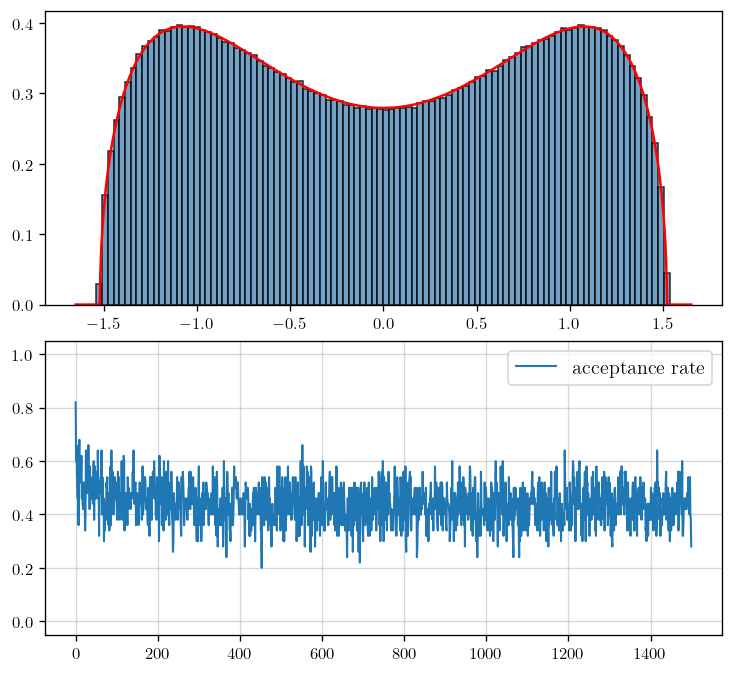

In [22]:
N = 300; beta = 2.0; T = 5.0; M = 50; 
potential_name = "quartic"; num_bins = 100;     
metropolise = True
dt = 1/N

total_steps = int(T/dt); init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

pipe = simulate.get_pipeline("imla", dt = dt, noise_scale = noise_scale, potential_type = potential_name, beta = beta, metropolise = metropolise)
traj = simulate.simulate_dbm(init, total_steps, pipe)

burn_in = int(3.0/dt) # at T = 3.0, for longer simulations change.
particles, accepts = simulate.metropolis_experiment(traj, total_steps, burn_in = burn_in, interval = 5)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, axes = plt.subplots(2, 1, figsize = (6, 5.5))
ax, ax2 = axes 

ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
ax.grid(False)

x_range = list(range(len(accepts)))
ax2.plot(x_range, accepts, label = "acceptance rate")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc = "upper right", fontsize = 12)

plt.show()

One hypothesis is the scaling needs to be about 1/N but needs testing in higher dimenions!

Working for N = 300.


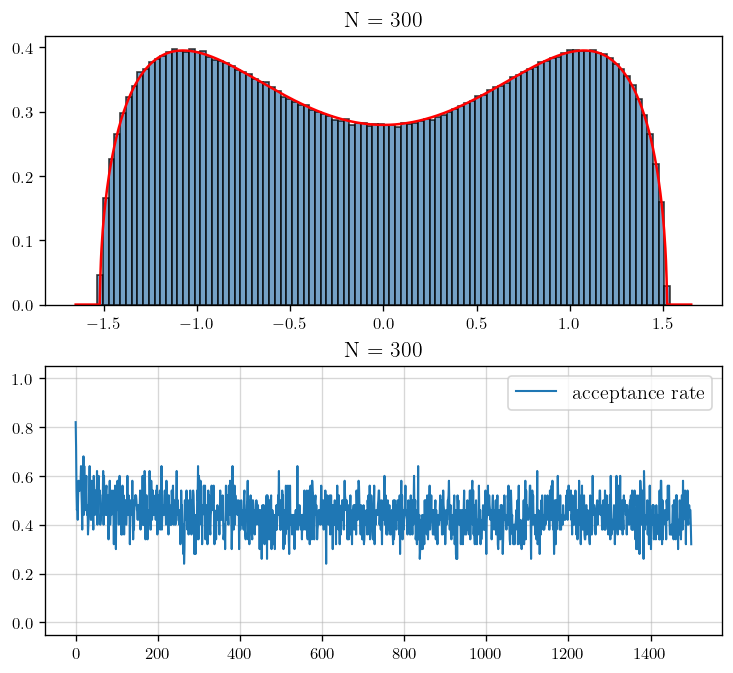

Working for N = 350.


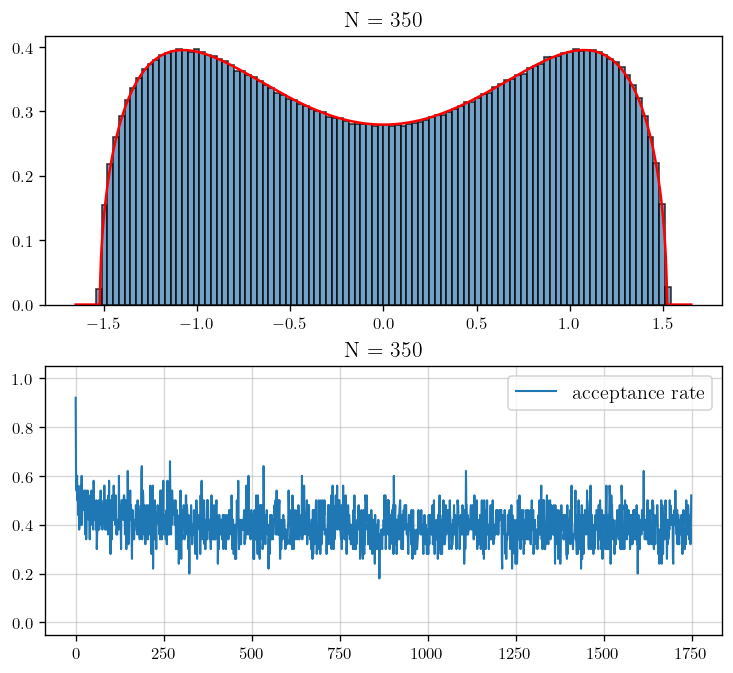

Working for N = 400.


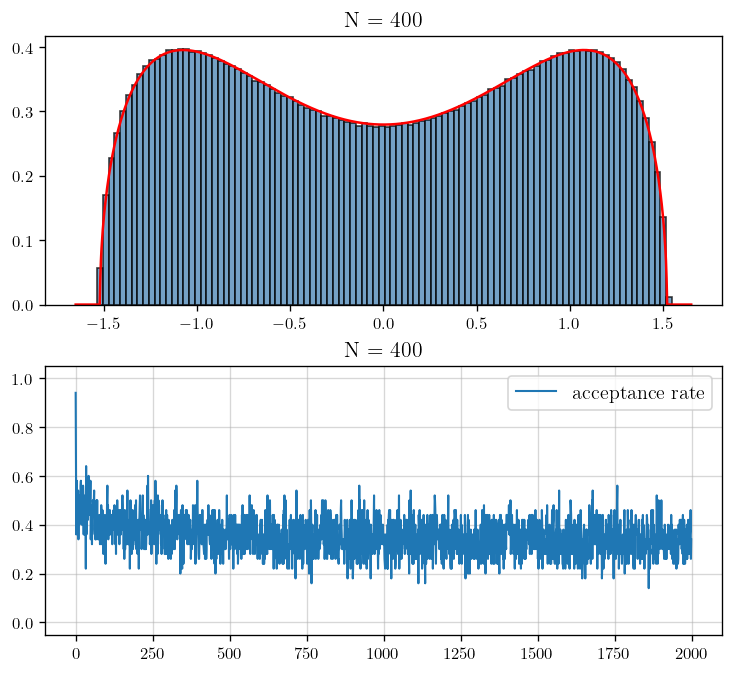

Working for N = 450.


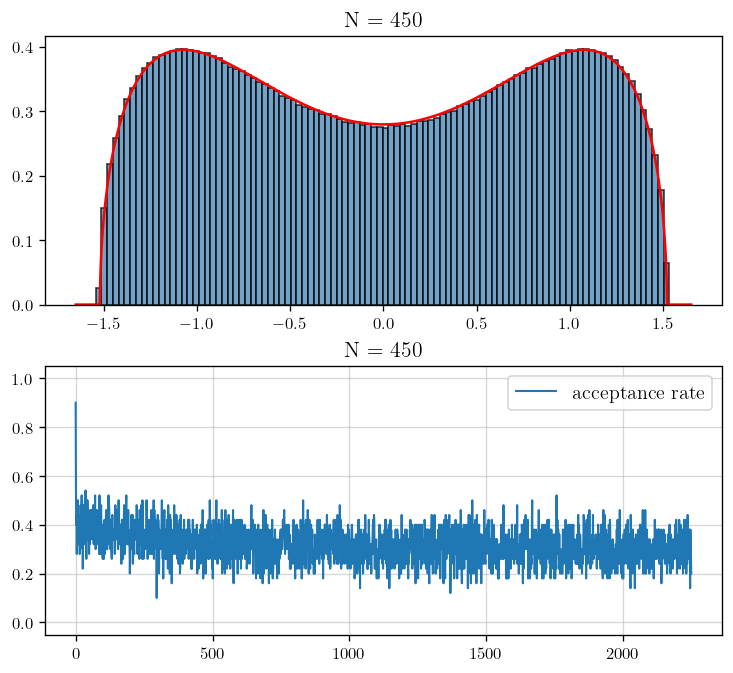

Working for N = 500.


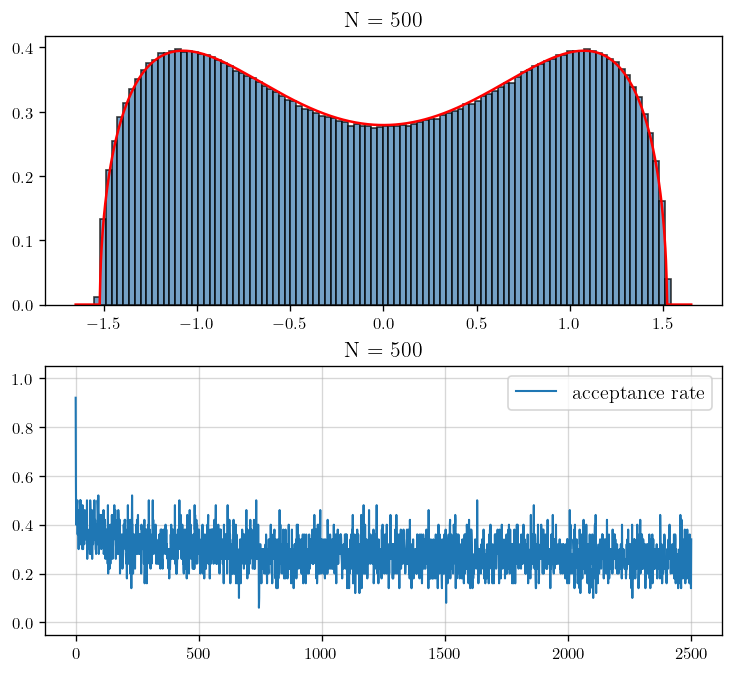

In [28]:
beta = 2.0; T = 5.0; M = 50; 
potential_name = "quartic"; num_bins = 100;     
metropolise = True

N_range = np.array([300, 350, 400, 450, 500])
for N in N_range:
    print(f"Working for N = {N}.")
    dt = 1/N
    total_steps = int(T/dt); init = random_matrix.init_gue_eigenvalues(M, N)
    noise_scale = np.sqrt(2.0*dt/(beta*N))

    pipe = simulate.get_pipeline("imla", dt = dt, noise_scale = noise_scale, potential_type = potential_name, beta = beta, metropolise = metropolise)
    traj = simulate.simulate_dbm(init, total_steps, pipe)

    burn_in = int(3.0/dt) # at T = 3.0, for longer simulations change.
    particles, accepts = simulate.metropolis_experiment(traj, total_steps, burn_in = burn_in, interval = 5)

    # Quick plotter.
    density_range, limiting_density = densities.get_density(potential_name)

    fig, axes = plt.subplots(2, 1, figsize = (6, 5.5))
    ax, ax2 = axes 

    ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
    ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
    ax.grid(False)
    ax.set_title(f"N = {N}")

    x_range = list(range(len(accepts)))
    ax2.plot(x_range, accepts, label = "acceptance rate")
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc = "upper right", fontsize = 12)
    ax2.set_title(f"N = {N}")

    plt.show()

In [29]:
1/500, 1/200, 1/100

(0.002, 0.005, 0.01)